# Importation

In [ ]:
# Import librairie
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
# Import du dataset nettoyé
df_final = pd.read_csv("df_final_clean.csv")

# Forcer Pandas à afficher les floats sans notation scientifique
pd.set_option("display.float_format", "{:,.2f}".format)

# Vérification rapide
print(df_final.shape)
df_final.head()

(128, 9)


,Country,Population,PIB par habitant (USD),Croissance PIB (%),Disponibilité volaille (kg/hab/an),Exportations (t),Indice logistique (0-5),Taux urbanisation (%),Taux autosuffisance (%)
0,Afghanistan,"36,296,113.00",525.47,2.65,1.53,0.00,1.95,24.83,50.42
1,Afrique du Sud,"57,009,756.00","6,618.34",1.16,35.69,"63,000.00",3.38,66.57,81.93
2,Albanie,"2,884,169.00","4,614.05",3.28,16.36,0.00,2.66,59.16,27.55
3,Algérie,"41,389,189.00","4,554.67",1.50,6.38,0.00,2.45,72.57,104.14
4,Allemagne,"82,658,409.00","45,526.60",2.72,19.47,"646,000.00",4.20,77.26,94.07


## Préparation des données pour l'ACP

In [ ]:
# Séparer l'identifiant (Country) et les variables numériques
X = df_final.drop(columns=["Country"])
countries = df_final["Country"]

# Vérifier les types de données
X.dtypes

,0
Population,float64
PIB par habitant (USD),float64
Croissance PIB (%),float64
Disponibilité volaille (kg/hab/an),float64
Exportations (t),float64
Indice logistique (0-5),float64
Taux urbanisation (%),float64
Taux autosuffisance (%),float64


In [ ]:
# Standariser les données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Vérification
print("Moyenne (après scaling) :", X_scaled.mean(axis=0))
print("Écart-type (après scaling) :", X_scaled.std(axis=0))

Moyenne (après scaling) : [ 0.00000000e+00 -4.16333634e-17  1.63064007e-16 -1.94289029e-16
  6.24500451e-17  7.04297731e-16 -2.08166817e-16 -3.81639165e-17]
Écart-type (après scaling) : [1. 1. 1. 1. 1. 1. 1. 1.]


On standardise les données pour l'ACP et le clustering.
StandardScaler calcule la moyenne et l'écart-type de chaque variable puis transforme chaque valeur en (x - moyenne)/écart-type. Après cette étape, toutes les variables ont une moyenne ≈ 0 et un écart-type ≈ 1,
ce qui les met sur la même échelle et empêche les variables aux grandes valeurs (ex : Population) d’écraser les autres (ex : Indice logistique).

## ACP exploratoire

In [ ]:
# Calculer l'ACP
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Variance expliquée par chaque composante
explained_variance = pca.explained_variance_ratio_

In [ ]:
# Affichage des résultats numériques
print("Variance expliquée par chaque composante :")
print(explained_variance)

print("\nVariance expliquée cumulée :")
print(np.cumsum(explained_variance))

Variance expliquée par chaque composante :
[0.35957656 0.17340508 0.12900034 0.10796501 0.08893328 0.07083252
 0.04653423 0.02375297]

Variance expliquée cumulée :
[0.35957656 0.53298164 0.66198198 0.76994699 0.85888028 0.9297128
 0.97624703 1.        ]


Composante 1 (PC1) : explique 36 % de l’information totale.

Composante 2 (PC2) : ajoute 17 % → ensemble PC1 + PC2 ≈ 53 %.

Composante 3 (PC3) : ≈ 13 % → cumul ≈ 66 %.

Composante 4 (PC4) : ≈ 10,8 % → cumul ≈ 77 %.

Chaque nouvelle composante explique de moins en moins d’information (loi du « palier décroissant »).

Avec 2 composantes, on récupère déjà 53 % de l’information totale.

Avec 4 composantes, on monte à 77 %.

Avec 6 composantes, on atteint 93 %.

Après 7–8 composantes, on frôle les 100 % → les suivantes apportent presque rien.

Conclusion : il est pertinent de travailler sur 4 composantes principales pour capturer l’essentiel de l’information (environ 77 %).

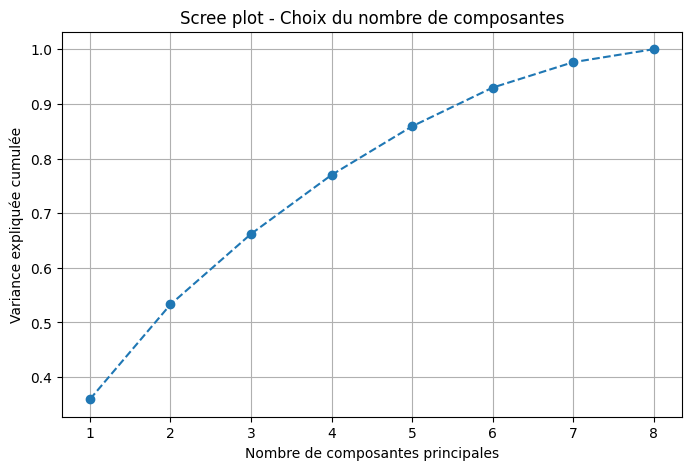

In [ ]:
# Visualisation

plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance)+1),
         np.cumsum(explained_variance),
         marker='o', linestyle='--')
plt.xlabel("Nombre de composantes principales")
plt.ylabel("Variance expliquée cumulée")
plt.title("Scree plot - Choix du nombre de composantes")
plt.grid(True)
plt.show()


On observe :

* PC1 capte environ 36 % de l’information.

* Avec PC1 + PC2, on monte déjà à environ 53 %.

* Avec PC1–PC4, on atteint 77 %.

* Les composantes suivantes apportent de moins en moins (PC5 +9 %, PC6 +7 %, PC7 +4 %).

 Le « coude » visuel se situe autour de 4 composantes : c’est le point où ajouter de nouvelles composantes n’apporte plus qu’un gain marginal.

 Conclusion : on retient 4 composantes principales pour capturer l’essentiel de l’information tout en simplifiant l’analyse.

### Visualisation de l'ACP

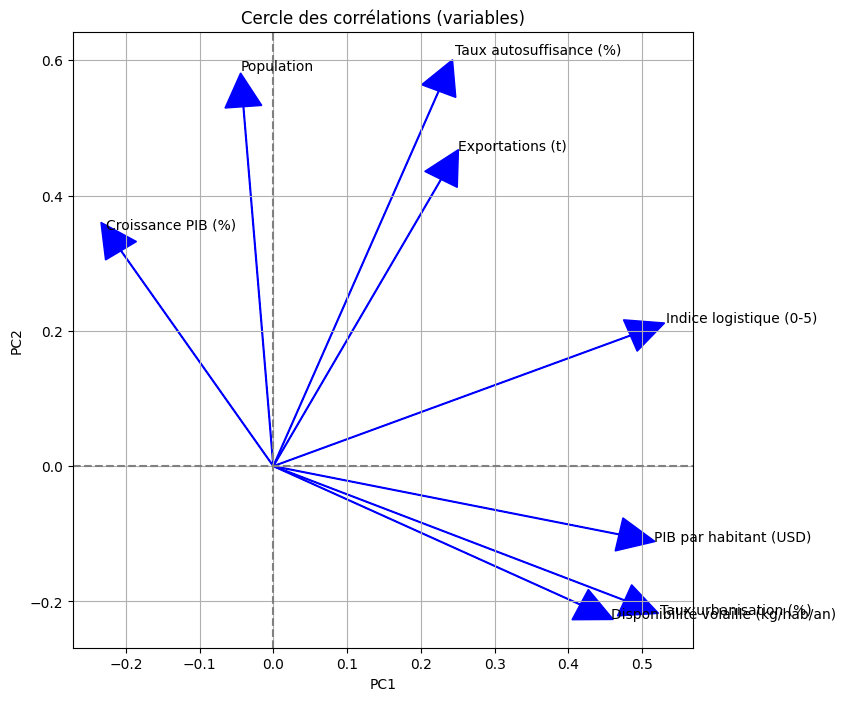

In [ ]:
# Cercle des corrélations

# On récupère les coordonnées des variables
components = pca.components_[:2]  # seulement PC1 et PC2
features = X.columns

plt.figure(figsize=(8,8))
plt.axhline(0, color="grey", linestyle="--")
plt.axvline(0, color="grey", linestyle="--")

for i, feature in enumerate(features):
    plt.arrow(0, 0, components[0, i], components[1, i],
              head_width=0.05, head_length=0.05, color="blue")
    plt.text(components[0, i]*1.1, components[1, i]*1.1, feature, color="black")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Cercle des corrélations (variables)")
plt.grid()
plt.show()

**Interprétation du cercle des corrélations :**

* Population et Taux d’autosuffisance (%) : ces deux variables sont projetées dans la même zone du graphique (en haut) → elles contribuent fortement à la première dimension et traduisent la taille et la capacité de production d’un pays.

* Exportations (t) est proche du Taux d’autosuffisance → plus un pays produit pour lui-même, plus il a tendance à exporter.

* PIB par habitant (USD) et Taux d’urbanisation (%) sont regroupés dans le coin droit → elles décrivent ensemble le niveau de développement économique et social.

* Indice logistique (0-5) est aussi orienté vers cette zone, traduisant la qualité des infrastructures (souvent corrélée au niveau de développement).

* Disponibilité volaille (kg/hab/an) est alignée avec PIB/hab et Taux d’urbanisation → cela montre qu’un meilleur niveau de vie est associé à une plus grande disponibilité alimentaire par habitant.

* Croissance PIB (%) est située plus à gauche et isolée → cette variable apporte une information différente, plus conjoncturelle (le rythme actuel de croissance) que structurelle

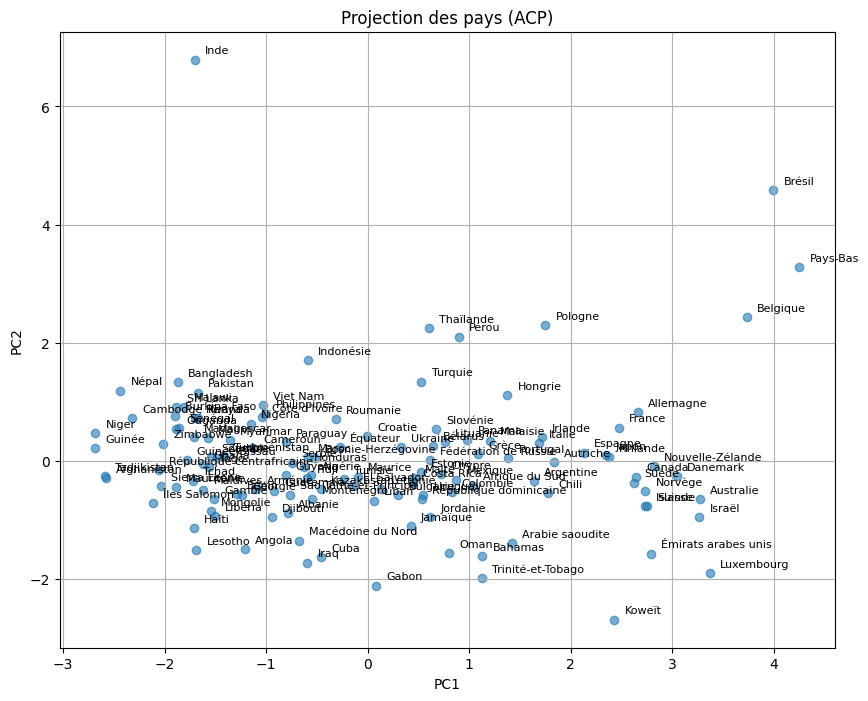

In [ ]:
# Projection des pays

plt.figure(figsize=(10,8))

# Projection des pays dans le plan factoriel (PC1, PC2)
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.6)

# Ajouter les noms des pays
for i, country in enumerate(countries):
    plt.text(X_pca[i,0]+0.1, X_pca[i,1]+0.1, country, fontsize=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Projection des pays (ACP)")
plt.grid()
plt.show()


**Interprétation de la projection des pays**

Le plan (PC1–PC2) sépare clairement :

* Sur PC1 (axe horizontal) : à droite, les pays à PIB/habitant élevé, logistique performante et fortes exportations (Pays-Bas, Belgique, Allemagne…) ; à gauche, les pays à faible PIB/habitant et infrastructures limitées (Niger, Cambodge…).

* Sur PC2 (axe vertical) : en haut, les pays avec population ou autosuffisance élevées (Inde, Pérou…) ; en bas, des profils atypiques riches mais petits (Luxembourg, Koweït…).

La majorité des pays est regroupée autour du centre (profil “moyen”), tandis que quelques pays isolés reflètent des caractéristiques extrêmes.

### Clustering

### Classification ascendante hiérarchique

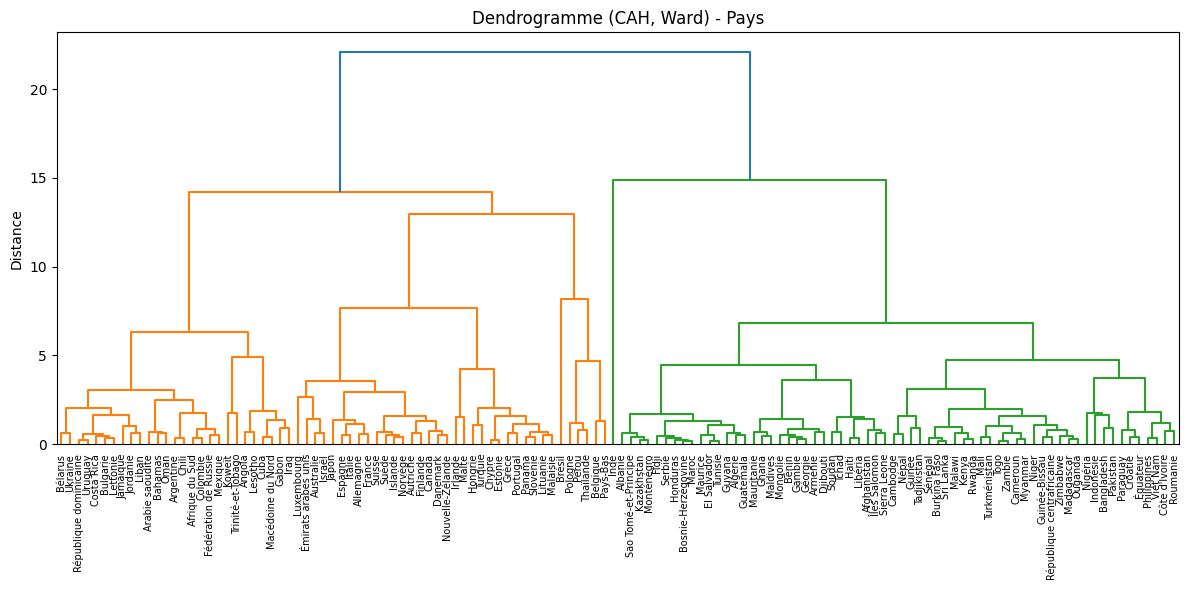

,count
cluster_h,
1,27
2,36
3,64
4,1


In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Réduire à 4 composantes (pour le clustering)
pca_4 = PCA(n_components=4, random_state=0)
X_pca4 = pca_4.fit_transform(X_scaled)

# CAH (méthode Ward)
Z = linkage(X_pca4, method="ward")

# Dendrogramme
plt.figure(figsize=(12, 6))
dendrogram(Z, labels=countries.values, leaf_rotation=90, leaf_font_size=7, color_threshold=None)
plt.title("Dendrogramme (CAH, Ward) - Pays")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# Couper l’arbre pour obtenir k clusters, ex. k=4
k = 4
clusters_h = fcluster(Z, t=k, criterion="maxclust")

# Attacher au dataframe pour analyse
df_clusters_h = pd.DataFrame({
    "Country": countries.values,
    "cluster_h": clusters_h
})

# Vue rapide
df_clusters_h["cluster_h"].value_counts().sort_index()

Le dendrogramme hiérarchique montre la manière dont les pays se regroupent en fonction de leurs caractéristiques :

Quatre grands groupes se dégagent :

* Cluster 1 (27 pays) : pays à haut niveau de développement et logistique performante (Europe de l’Ouest, pays riches).

* Cluster 2 (36 pays) : pays intermédiaires, souvent émergents, avec urbanisation moyenne.

* Cluster 3 (64 pays) : pays à faibles revenus, infrastructures limitées et autosuffisance modérée.

* Cluster 4 (1 pays) : un cas extrême isolé, dont le profil est très différent des autres (outlier).

Plus les branches sont longues avant de fusionner, plus les groupes sont différents. Ici, la séparation entre les clusters 1, 2 et 3 est nette, et le cluster 4 représente un profil vraiment atypique.

### K-means

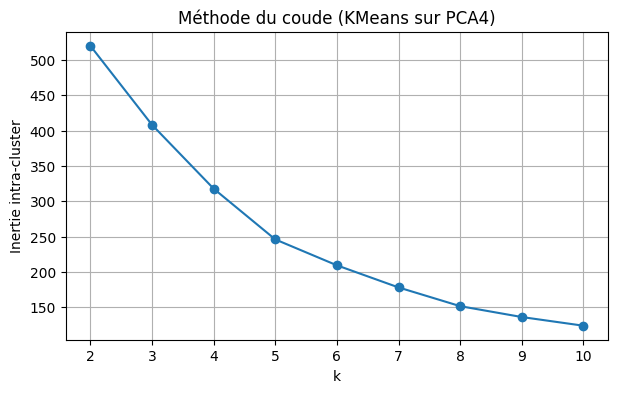

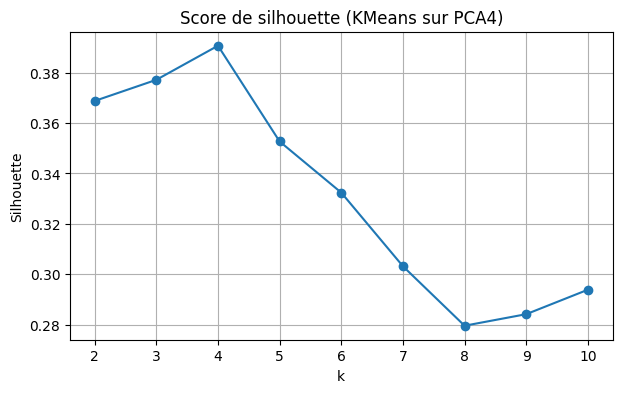

k choisi : 4


,count
cluster_km,
0,6
1,51
2,70
3,1


In [ ]:
# Plage de k
Ks = range(2, 11)
inertias = []
silhs = []

for k in Ks:
    km = KMeans(n_clusters=k, n_init=50, random_state=0)
    labels = km.fit_predict(X_pca4)
    inertias.append(km.inertia_)
    silhs.append(silhouette_score(X_pca4, labels))

# Courbe du coude (inertie)
plt.figure(figsize=(7,4))
plt.plot(Ks, inertias, marker='o')
plt.xlabel("k")
plt.ylabel("Inertie intra-cluster")
plt.title("Méthode du coude (KMeans sur PCA4)")
plt.grid(True)
plt.show()

# Courbe silhouette
plt.figure(figsize=(7,4))
plt.plot(Ks, silhs, marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.title("Score de silhouette (KMeans sur PCA4)")
plt.grid(True)
plt.show()

# Choisis k (exemple: au coude et proche du max silhouette)
k_opt = Ks[int(np.argmax(silhs))]  # ou fixe manuellement après lecture des graphes
print("k choisi :", k_opt)

# Modèle final
kmeans = KMeans(n_clusters=k_opt, n_init=50, random_state=0)
labels_final = kmeans.fit_predict(X_pca4)

# Ajouter au tableau
df_kmeans = pd.DataFrame({"Country": countries.values, "cluster_km": labels_final})
df_kmeans["cluster_km"].value_counts().sort_index()


**Méthode du coude (inertie intra-cluster)**

On observe une forte baisse de l’inertie quand on passe de k=2 à k=4, puis la courbe s’aplatit progressivement.

Cela signifie que l’ajout de clusters après k=4 apporte des gains de compacité beaucoup plus faibles.

Le “coude” est donc autour de k=4, ce qui suggère que 4 groupes expliquent déjà bien la structure des données.

**Score de silhouette**

Le score mesure la séparation et la cohésion des clusters (plus proche de 1 = mieux).

Le meilleur score est obtenu pour k=4 (~0,39) : c’est là où les clusters sont le plus distincts tout en restant compacts.

Ensuite, le score baisse progressivement (k>4) → les clusters deviennent moins nets.

### Projection des pays par cluster

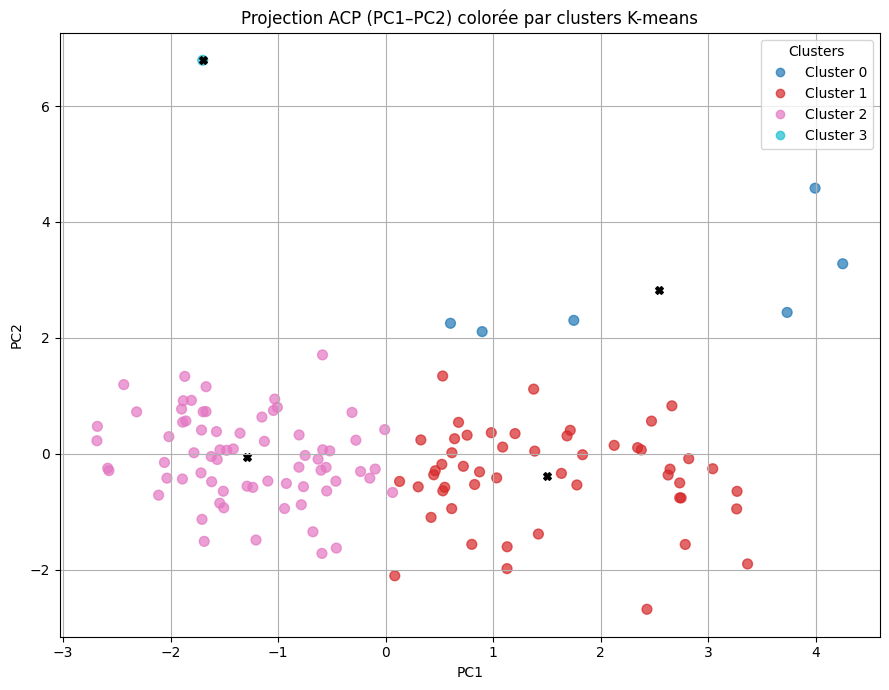

In [ ]:
# Projection 2D depuis les 4 composantes utilisées pour KMeans
X_pca2_for_plot = X_pca4[:, :2]          # PC1, PC2 des données PCA(4)
centers_2d = kmeans.cluster_centers_[:, :2]  # centres projetés sur PC1–PC2

# --- Palette contrastée (tab10 contient 10 couleurs distinctes) ---
from matplotlib import colormaps
cmap = colormaps.get_cmap('tab10').resampled(len(np.unique(kmeans.labels_)))

plt.figure(figsize=(9,7))
sc = plt.scatter(X_pca2_for_plot[:,0], X_pca2_for_plot[:,1],
                 c=kmeans.labels_, cmap=cmap, alpha=0.7, s=50)

# centres des clusters
plt.scatter(centers_2d[:,0], centers_2d[:,1],
            marker="X", s=30, edgecolor="k", linewidth=1.0, c="black")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Projection ACP (PC1–PC2) colorée par clusters K-means")
plt.grid(True)

# légende avec les mêmes couleurs
handles, _ = sc.legend_elements(prop="colors", alpha=0.7)
plt.legend(handles, [f"Cluster {i}" for i in sorted(set(kmeans.labels_))],
           title="Clusters", loc="best")

plt.tight_layout()
plt.show()



**Lecture globale**

Le nuage de points correspond aux pays projetés sur les deux premières composantes principales (PC1 et PC2). Les couleurs représentent les 4 clusters K-means et les petits « X » noirs indiquent les centres de chaque cluster.

**Interprétation des regroupements**

* Cluster 0 (bleu) : pays atypiques (Inde, Brésil, Pays-Bas…) caractérisés par une forte population ou des exportations très élevées (outliers).

* Cluster 1 (rouge) : rassemble des pays plus orientés « PIB moyen mais exportations/urbanisation différentes » que le cluster 2.

* Cluster 2 (rose) : regroupe la majorité des pays, profils « intermédiaires » avec des valeurs moyennes sur la plupart des indicateurs.

* Cluster 3 (cyan) : un tout petit cluster, quasi un point isolé, représentant un pays très particulier (extrême sur certains indicateurs).

**Conclusion**

La projection montre que la majorité des pays se concentre autour du centre (clusters 1 et 2), tandis que quelques pays forment des groupes distincts en périphérie (clusters 0 et 3) du fait de caractéristiques extrêmes (population, exportations ou autosuffisance).

### Interprétation des clusters

In [ ]:
# Ajouter les clusters au dataframe original
df_final["cluster_km"] = kmeans.labels_

# Calculer les moyennes par cluster
cluster_summary = df_final.groupby("cluster_km").mean(numeric_only=True)

cluster_summary

,Population,PIB par habitant (USD),Croissance PIB (%),Disponibilité volaille (kg/hab/an),Exportations (t),Indice logistique (0-5),Taux urbanisation (%),Taux autosuffisance (%)
cluster_km,,,,,,,,
0,"62,480,367.67","21,782.02",2.90,22.95,"1,353,166.67",3.45,77.07,252.99
1,"24,492,852.82","29,530.88",2.89,29.74,"81,294.12",3.27,78.88,94.56
2,"27,896,586.36","3,359.45",4.33,9.98,"2,085.71",2.54,47.25,71.58
3,"1,338,676,785.00","1,950.10",6.80,2.22,"4,000.00",3.18,34.13,119.29


**Interprétation des clusters K-Means (k=4)**

* Cluster 0 : pays développés exportateurs, très autosuffisants avec forte production et volumes d’exportation.

* Cluster 1 : pays riches et urbanisés, autosuffisants mais avec des exportations plus limitées.

* Cluster 2 : pays en développement à faible revenu, faible consommation et dépendants des importations.

* Cluster 3 : très grands pays à bas revenu, forte autosuffisance mais consommation par habitant très faible.

### Lister les pays par cluster

In [ ]:
# Lister les pays par cluster K-means
pays_par_cluster = df_final.groupby('cluster_km')['Country'].apply(list)

for cluster, pays in pays_par_cluster.items():
    print(f"\nCluster {cluster} ({len(pays)} pays) :")
    print(', '.join(pays))



Cluster 0 (6 pays) :
Belgique, Brésil, Pays-Bas, Pérou, Pologne, Thaïlande

Cluster 1 (51 pays) :
Afrique du Sud, Allemagne, Arabie saoudite, Argentine, Australie, Autriche, Bahamas, Bélarus, Bulgarie, Canada, Chili, Chypre, Colombie, Costa Rica, Danemark, Émirats arabes unis, Espagne, Estonie, Fédération de Russie, Finlande, France, Gabon, Grèce, Hongrie, Irlande, Islande, Israël, Italie, Jamaïque, Japon, Jordanie, Koweït, Lettonie, Lituanie, Luxembourg, Malaisie, Malte, Mexique, Norvège, Nouvelle-Zélande, Oman, Panama, Portugal, République dominicaine, Slovénie, Suède, Suisse, Trinité-et-Tobago, Turquie, Ukraine, Uruguay

Cluster 2 (70 pays) :
Afghanistan, Albanie, Algérie, Angola, Arménie, Bangladesh, Bénin, Bosnie-Herzégovine, Burkina Faso, Cambodge, Cameroun, Côte d'Ivoire, Croatie, Cuba, Djibouti, El Salvador, Équateur, Fidji, Gambie, Géorgie, Ghana, Guatemala, Guinée, Guinée-Bissau, Guyana, Haïti, Honduras, Îles Salomon, Indonésie, Iraq, Kazakhstan, Kenya, Lesotho, Liban, Libér

### Vérification de la stabilité CAH / K-means

In [ ]:
# 1) Labels CAH sur PCA(4) (même espace que K-means)
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import adjusted_rand_score
import pandas as pd

# Si tu as déjà X_pca4 (les 4 premières composantes) et df_final avec 'cluster_km' :
# X_pca4 = pca.fit_transform(X_scaled)[:, :4]

Z = linkage(X_pca4, method="ward")          # matrice de liaison
labels_cah = fcluster(Z, t=4, criterion="maxclust")  # 4 clusters
df_final["cluster_cah"] = labels_cah

# 2) Tableau croisé CAH vs K-means
tab_stabilite = pd.crosstab(df_final["cluster_cah"], df_final["cluster_km"])
print("Tableau croisé CAH (lignes) vs K-means (colonnes) :\n")
print(tab_stabilite)

# 3) Indice de similarité (plus c’est proche de 1, plus l’accord est fort)
ari = adjusted_rand_score(df_final["cluster_cah"], df_final["cluster_km"])
print(f"\nAdjusted Rand Index (CAH vs K-means) : {ari:.3f}")

# (optionnel) aperçu des pays par double affectation
apercu = df_final[["Country","cluster_cah","cluster_km"]].sort_values(["cluster_cah","cluster_km"])
apercu.head(15)



Tableau croisé CAH (lignes) vs K-means (colonnes) :

cluster_km   0   1   2  3
cluster_cah              
1            0  21   6  0
2            6  30   0  0
3            0   0  64  0
4            0   0   0  1

Adjusted Rand Index (CAH vs K-means) : 0.667


,Country,cluster_cah,cluster_km
1,Afrique du Sud,1,1
6,Arabie saoudite,1,1
7,Argentine,1,1
11,Bahamas,1,1
13,Bélarus,1,1
18,Bulgarie,1,1
23,Chili,1,1
25,Colombie,1,1
26,Costa Rica,1,1
37,Fédération de Russie,1,1


**Interprétation**

Nous avons appliqué deux méthodes de segmentation (CAH : classification ascendante hiérarchique  et K-means) puis comparé leurs résultats. L’objectif est de vérifier la stabilité des clusters : si les deux méthodes produisent des regroupements proches, cela renforce la fiabilité de notre segmentation.

Ici, l’indice ARI = 0,67 montre une bonne cohérence entre les deux méthodes : la majorité des pays sont classés dans les mêmes groupes, seuls quelques pays diffèrent car ils ont un profil intermédiaire ou atypique. Cela confirme que nos clusters sont globalement robustes et crédibles.

### Extraction des pays cibles

In [ ]:
def filtrer(df, pop_min, auto_max, pib_min, lpi_min, dispo_min):
    num_cols = [
        "Population","PIB par habitant (USD)","Croissance PIB (%)",
        "Disponibilité volaille (kg/hab/an)","Exportations (t)",
        "Indice logistique (0-5)","Taux urbanisation (%)","Taux autosuffisance (%)"
    ]
    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    mask = (
        (df["Population"] >= pop_min) &
        (df["Taux autosuffisance (%)"] < auto_max) &
        (df["PIB par habitant (USD)"] >= pib_min) &
        (df["Indice logistique (0-5)"] >= lpi_min) &
        (df["Disponibilité volaille (kg/hab/an)"] >= dispo_min)
    )
    cols = ["Country","Population","PIB par habitant (USD)","Indice logistique (0-5)",
            "Taux autosuffisance (%)","Disponibilité volaille (kg/hab/an)","cluster_km"]
    return (df.loc[mask, cols]
              .sort_values(["Taux autosuffisance (%)","Population"], ascending=[True, False])
              .reset_index(drop=True))

scenarios = {
    "Standard":   dict(pop_min=10_000_000, auto_max=70, pib_min=5_000, lpi_min=2.6, dispo_min=8),
    "Volume":     dict(pop_min=5_000_000,  auto_max=80, pib_min=3_000, lpi_min=2.5, dispo_min=6),
    "Premium":    dict(pop_min=3_000_000,  auto_max=65, pib_min=10_000,lpi_min=3.0, dispo_min=12),
    "Frontier":   dict(pop_min=10_000_000, auto_max=70, pib_min=2_000, lpi_min=2.3, dispo_min=6),
}

resultats = {}
for nom, p in scenarios.items():
    df_sel = filtrer(df_final.copy(), **p)
    resultats[nom] = df_sel
    print(f"{nom}: {len(df_sel)} pays")



Standard: 2 pays
Volume: 6 pays
Premium: 3 pays
Frontier: 4 pays


Interprétation des scénarios de pays cibles

Pour identifier des marchés potentiels d’exportation, nous avons testé plusieurs scénarios en modulant les critères (population, niveau de revenu, infrastructures logistiques, dépendance alimentaire).

* Scénario “Standard” (critères exigeants) ne retient que 2 pays : Arabie Saoudite et Émirats Arabes Unis — de grands marchés solvables, très dépendants des importations de volaille.

* Scénario “Volume” (critères plus ouverts) retient 6 pays dont Kazakhstan, Bulgarie, Suisse et Jordanie — marchés de taille moyenne ou grande, revenus corrects et dépendance alimentaire notable.

* Scénario “Premium” cible 3 pays à haut revenu mais taille plus réduite (niche solvable).

* Scénario “Frontier” sélectionne 4 pays à potentiel démographique important mais infrastructures logistiques plus fragiles (marchés à développer).

In [ ]:
from IPython.display import display, Markdown
import pandas as pd

# Colonnes à afficher
cols_aff = ["Country","Population","PIB par habitant (USD)","Indice logistique (0-5)",
            "Taux autosuffisance (%)","Disponibilité volaille (kg/hab/an)","cluster_km"]

def format_table(df):
    df = df.copy()
    df = df.sort_values(["Taux autosuffisance (%)","Population"], ascending=[True, False])
    # arrondis
    df["Population"] = pd.to_numeric(df["Population"], errors="coerce").round(0).astype("Int64")
    df["PIB par habitant (USD)"] = pd.to_numeric(df["PIB par habitant (USD)"], errors="coerce").round(0).astype("Int64")
    df["Indice logistique (0-5)"] = pd.to_numeric(df["Indice logistique (0-5)"], errors="coerce").round(2)
    df["Taux autosuffisance (%)"] = pd.to_numeric(df["Taux autosuffisance (%)"], errors="coerce").round(1)
    df["Disponibilité volaille (kg/hab/an)"] = pd.to_numeric(df["Disponibilité volaille (kg/hab/an)"], errors="coerce").round(1)
    return df[cols_aff]

# Affichage de chaque scénario (suppose que 'resultats' contient les 4 DataFrames)
for nom, df_sel in resultats.items():
    display(Markdown(f"### {nom} — {len(df_sel)} pays"))
    display(format_table(df_sel).reset_index(drop=True))


### Standard — 2 pays

,Country,Population,PIB par habitant (USD),Indice logistique (0-5),Taux autosuffisance (%),Disponibilité volaille (kg/hab/an),cluster_km
0,Arabie saoudite,33101179,23929,3.01,42.90,43.40,1
1,Kazakhstan,18080019,8943,2.81,51.80,18.30,2


### Volume — 6 pays

,Country,Population,PIB par habitant (USD),Indice logistique (0-5),Taux autosuffisance (%),Disponibilité volaille (kg/hab/an),cluster_km
0,Émirats arabes unis,9487203,42341,3.96,11.60,43.50,1
1,Arabie saoudite,33101179,23929,3.01,42.90,43.40,1
2,Kazakhstan,18080019,8943,2.81,51.80,18.30,2
3,Bulgarie,7102444,8697,3.03,68.30,22.10,1
4,Suisse,8455804,82254,3.90,68.50,15.70,1
5,Jordanie,9785843,4066,2.69,76.40,28.10,1


### Premium — 3 pays

,Country,Population,PIB par habitant (USD),Indice logistique (0-5),Taux autosuffisance (%),Disponibilité volaille (kg/hab/an),cluster_km
0,Oman,4665928,17820,3.20,6.90,21.60,1
1,Émirats arabes unis,9487203,42341,3.96,11.60,43.50,1
2,Arabie saoudite,33101179,23929,3.01,42.90,43.40,1


### Frontier — 4 pays

,Country,Population,PIB par habitant (USD),Indice logistique (0-5),Taux autosuffisance (%),Disponibilité volaille (kg/hab/an),cluster_km
0,Ghana,29121465,2012,2.57,28.50,7.20,2
1,Arabie saoudite,33101179,23929,3.01,42.90,43.40,1
2,Kazakhstan,18080019,8943,2.81,51.80,18.30,2
3,Guatemala,16914970,4325,2.41,67.50,20.60,2


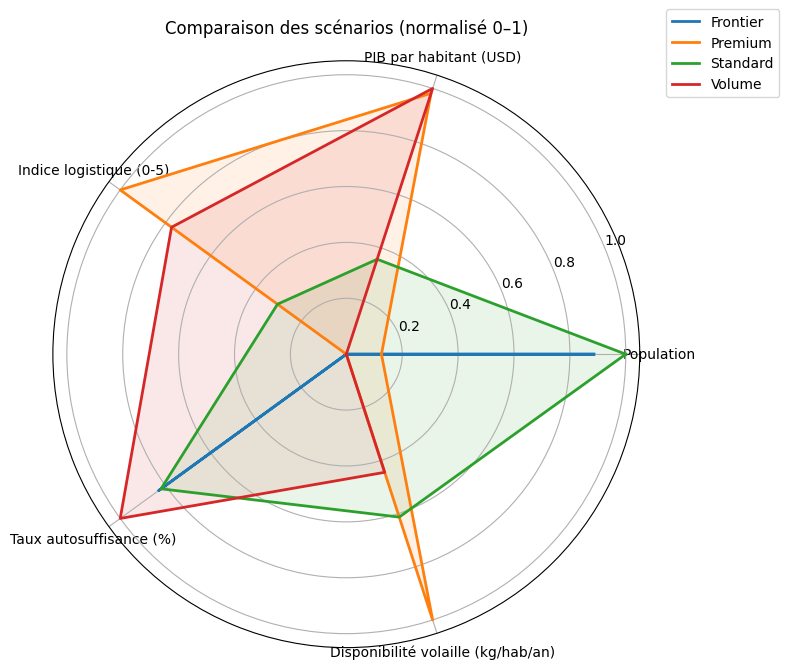

In [ ]:
# 1) Construire df_scenarios depuis le dict `resultats`
dfs = []
for nom, df_sel in resultats.items():
    tmp = df_sel.copy()
    tmp["Scenario"] = nom
    dfs.append(tmp)
df_scenarios = pd.concat(dfs, ignore_index=True)

# 2) Assurer les types numériques
num_cols = [
    "Population","PIB par habitant (USD)","Indice logistique (0-5)",
    "Taux autosuffisance (%)","Disponibilité volaille (kg/hab/an)"
]
for c in num_cols:
    df_scenarios[c] = pd.to_numeric(df_scenarios[c], errors="coerce")

# 3) Résumé moyen par scénario
summary = df_scenarios.groupby("Scenario")[num_cols].mean()

# 4) Radar plot (valeurs brutes)
categories = summary.columns.tolist()
N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

# (Option) Radar normalisé 0-1 pour comparabilité visuelle
norm = (summary - summary.min()) / (summary.max() - summary.min())
plt.figure(figsize=(8, 8))
for scenario, row in norm.iterrows():
     values = row.tolist() + row.tolist()[:1]
     plt.polar(angles, values, label=scenario, linewidth=2)
     plt.fill(angles, values, alpha=0.1)
plt.xticks(angles[:-1], categories, fontsize=10)
plt.title("Comparaison des scénarios (normalisé 0–1)", pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1))
plt.tight_layout(); plt.show()


**Interprétation du graphique radar normalisé**

Chaque axe représente un indicateur clé (Population, PIB/habitant, Indice logistique, Taux d’autosuffisance, Disponibilité volaille).

Chaque couleur représente un scénario (Frontier, Premium, Standard, Volume).

Les valeurs sont normalisées entre 0 et 1, donc plus la courbe est proche du bord du cercle, plus l’indicateur est élevé dans ce scénario par rapport aux autres.

🔹 Frontier (bleu) :
Très forte population, mais PIB/habitant et logistique faibles ; taux d’autosuffisance moyen. → Cibles avec gros volumes potentiels mais marché peu structuré.

🔹 Premium (orange) :
Très haut PIB/habitant et très bon indice logistique, mais population faible. → Marchés riches et bien organisés, mais taille limitée.

🔹 Standard (vert) :
Profil équilibré : population importante, taux d’autosuffisance correct, indicateurs moyens sur tous les axes. → Marchés intermédiaires.

🔹 Volume (rouge) :
Très bons taux d’autosuffisance et logistique, population moyenne, PIB/habitant élevé. → Marchés capables d’absorber du volume mais déjà en partie autosuffisants.

📌 En résumé :
Le graphique montre visuellement comment chaque scénario se positionne :
- Frontier = gros volumes mais faible pouvoir d’achat/logistique,
- Premium = marchés riches mais petits,
- Standard = compromis,
- Volume = marchés matures avec bonne logistique mais déjà producteurs.